<a href="https://colab.research.google.com/github/PutriBalqis134/FYP-HNSCC/blob/main/DNN_mRNA_ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Input, Dense, Embedding, Flatten, Concatenate, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2


In [ ]:
# Load sample info for cell line ID mapping
sample_info = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/sample_info_updated.csv')
print("Sample Info Shape:", sample_info.shape)
display(sample_info.head())

Sample Info Shape: (120, 2)


,depmapId,cellLineDisplayName
0,ACH-000740,A253
1,ACH-002212,BB30HNC
2,ACH-002213,BB49HNC
3,ACH-000548,BHY
4,ACH-001331,BICR10


In [ ]:
# Load mRNA expression data
mrna = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/mRNAexp_HNSCC_filtered.csv')
mrna = mrna.set_index("depmapId")

print("mRNA expression Data Shape:", mrna.shape)
display(mrna.head())


mRNA expression Data Shape: (87, 16383)


,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),NFYA (4800),...,ZNF772 (400720),ZNF257 (113835),PCNX3 (399909),ADAM32 (203102),ACSL5 (51703),LRRC8B (23507),ABCB8 (11194),H3C12 (8356),SND1 (27044),ZNF785 (146540)
depmapId,,,,,,,,,,,,,,,,,,,,,
ACH-000740,0.070389,0.0,6.782409,1.427606,3.371559,0.014355,1.378512,5.505573,4.245648,3.711495,...,0.042644,0.000000,4.714246,0.344828,0.176323,1.933573,3.645010,0.687061,6.331275,2.946731
ACH-000548,4.694323,0.0,6.706116,1.985500,3.160275,0.400538,4.670161,5.866908,5.122259,3.757023,...,2.304511,0.000000,6.096346,1.063503,3.323370,3.922198,4.621173,0.000000,6.665052,4.429616
ACH-000503,3.094236,0.0,5.843733,1.189034,2.372952,0.150560,1.985500,5.176323,5.262283,3.092546,...,1.495695,1.049631,4.126808,0.432959,0.189034,1.298658,2.961623,0.432959,5.994806,1.937344
ACH-000794,2.625270,0.0,5.509062,1.510962,1.794936,0.238787,3.114367,4.707083,4.924575,2.763412,...,0.250962,0.056584,4.331275,0.263034,2.477677,1.981853,2.646163,0.124328,5.658783,1.959770
ACH-000228,4.120186,0.0,6.420550,2.053111,3.204767,0.594549,3.937344,6.168522,4.856488,3.622930,...,2.173127,0.000000,5.549669,1.220330,3.228049,1.632268,4.841973,0.389567,6.745372,3.111031


In [ ]:
# Load drug response data (logIC50)
ic50_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Datasets/HNSCC_IC50.csv')
print("GDSC IC50 Shape:", ic50_df.shape)
display(ic50_df.head())

GDSC IC50 Shape: (9408, 12)


,Drug Name,Drug ID,cellLineDisplayName,Cosmic ID,TCGA Classification,Tissue,Tissue Sub-type,IC50,AUC,Max Conc,RMSE,Z score
0,Camptothecin,1003,BB30HNC,753531,HNSC,aero_digestive_tract,head_and_neck,-4.016599,0.729320,0.1,0.121919,-0.956747
1,Camptothecin,1003,BB49HNC,753532,HNSC,aero_digestive_tract,head_and_neck,-2.024280,0.867884,0.1,0.109995,0.128007
2,Camptothecin,1003,BHY,753535,HNSC,aero_digestive_tract,head_and_neck,-2.081150,0.872193,0.1,0.068698,0.097043
3,Camptothecin,1003,Ca922,753538,HNSC,aero_digestive_tract,head_and_neck,-3.523805,0.764404,0.1,0.095041,-0.688436
4,Camptothecin,1003,CAL33,753541,HNSC,aero_digestive_tract,head_and_neck,-3.711201,0.746475,0.1,0.094559,-0.790468


In [ ]:
#build mapping table to align key ids from all datasets
map_df = sample_info[["depmapId", "cellLineDisplayName"]].drop_duplicates()

#merge ic50 dataset with with sample info to align depmapId
ic50 = ic50_df.merge(
    map_df,
    on="cellLineDisplayName",
    how="inner"
)

ic50 = ic50[["depmapId", "Drug Name", "IC50"]]

print(ic50_df.shape)
print(ic50.shape)
ic50.head()

(9408, 12)
(9127, 3)


,depmapId,Drug Name,IC50
0,ACH-002212,Camptothecin,-4.016599
1,ACH-002213,Camptothecin,-2.024280
2,ACH-000548,Camptothecin,-2.081150
3,ACH-002043,Camptothecin,-3.523805
4,ACH-000518,Camptothecin,-3.711201


In [ ]:

# -------------------------------
# 7️⃣ Merge RNA-seq with mapped IC50
# -------------------------------
merged_df = pd.merge(
    ic50,
    mrna,
    left_on='depmapId',
    right_on='depmapId',
    how='inner'
)

print("Merged mRNA + IC50 Shape:", merged_df.shape)
display(merged_df.head())


Merged mRNA + IC50 Shape: (5647, 16386)


,depmapId,Drug Name,IC50,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),...,ZNF772 (400720),ZNF257 (113835),PCNX3 (399909),ADAM32 (203102),ACSL5 (51703),LRRC8B (23507),ABCB8 (11194),H3C12 (8356),SND1 (27044),ZNF785 (146540)
0,ACH-000548,Camptothecin,-2.081150,4.694323,0.000000,6.706116,1.985500,3.160275,0.400538,4.670161,...,2.304511,0.000000,6.096346,1.063503,3.323370,3.922198,4.621173,0.000000,6.665052,4.429616
1,ACH-000518,Camptothecin,-3.711201,3.865919,0.000000,6.770168,2.241840,3.003602,0.356144,5.979111,...,2.558268,0.084064,5.153400,0.176323,4.375735,2.722466,4.525443,0.189034,7.005625,2.773996
2,ACH-002045,Camptothecin,-1.717440,4.335569,0.000000,7.003939,2.286881,3.851999,0.000000,4.945327,...,1.432959,1.731183,4.245648,0.286881,0.189034,2.443607,2.877744,2.195348,6.474112,0.014355
3,ACH-000472,Camptothecin,-4.336130,3.243364,0.014355,6.756490,1.321928,2.166715,0.042644,4.201634,...,1.244887,1.189034,4.718088,0.214125,0.879706,1.321928,3.667892,0.000000,6.050284,2.533563
4,ACH-001543,Camptothecin,-3.099968,4.073820,0.000000,7.050937,1.847997,3.747387,0.097611,3.886550,...,1.799087,2.543496,5.209843,0.238787,0.400538,1.327687,3.602884,0.226509,5.638943,1.996389


In [ ]:
# Drop columns that are entirely NaN from merged_df before feature selection
merged_df_cleaned = merged_df.dropna(axis=1, how='all')

# Prepare X (features) and y (target)
# Select only numerical and boolean columns for X from the cleaned DataFrame
# Exclude 'DepMap_ID' as it's an identifier and 'logIC50' as it's the target
feature_columns = merged_df_cleaned.select_dtypes(include=[np.number, bool]).columns.tolist()

# Ensure 'logIC50' is not in feature_columns if it somehow got included or was numeric
if 'IC50' in feature_columns:
    feature_columns.remove('IC50')
# Ensure 'DepMap_ID' is not in feature_columns if it somehow got included
if 'depmapId' in feature_columns:
    feature_columns.remove('depmapId')

X = merged_df_cleaned[feature_columns].values
y = merged_df_cleaned['IC50'].values

print(f"Final X shape: {X.shape}")
print(f"Final y shape: {y.shape}")

Final X shape: (5647, 16383)
Final y shape: (5647,)


In [ ]:
drug_encoder = LabelEncoder()

merged_df_cleaned["Drug_ID"] = drug_encoder.fit_transform(
    merged_df_cleaned["Drug Name"]
)

num_drugs = merged_df_cleaned["Drug_ID"].nunique()

print("Number of drugs:", num_drugs)

Number of drugs: 288


In [ ]:
#feature selection

#Filter out genes with >95% zero expression
zero_threshold = 0.85
zero_counts = (merged_df_cleaned[feature_columns] == 0).sum() / len(merged_df_cleaned)
keep_columns = zero_counts[zero_counts <= zero_threshold].index.tolist()

print(f"Original features: {len(feature_columns)}")
print(f"Features after removing high-zero columns: {len(keep_columns)}")


# mRNA features
X_gene = merged_df_cleaned[keep_columns].values

# Drug IDs
X_drug = merged_df_cleaned["Drug_ID"].values

# Target
y = merged_df_cleaned["IC50"].values

print(X_gene.shape)
print(X_drug.shape)
print(y.shape)

Original features: 16383
Features after removing high-zero columns: 15470
(5647, 15470)
(5647,)
(5647,)


### Train-Test Split and Data Normalization

We'll split the data into training (80%) and testing (20%) sets. Then, the input features (mRNA expression) will be normalized using `StandardScaler` to have a mean of 0 and a standard deviation of 1. This is crucial for neural network performance.

In [ ]:
# Split data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Split data into training and testing sets, and also get the original indices
indices = np.arange(len(X_gene)) # Create an array of original indices
(
    X_gene_train,
    X_gene_test,
    X_drug_train,
    X_drug_test,
    y_train,
    y_test,
    train_idx,
    test_idx
) = train_test_split(
    X_gene,
    X_drug,
    y,
    indices,
    test_size=0.2,
    random_state=42
)

# Data Normalization
scaler = StandardScaler()
X_gene_train = scaler.fit_transform(X_gene_train)
X_gene_test = scaler.transform(X_gene_test)

print("Data normalized successfully.")

Data normalized successfully.


In [ ]:
selector = SelectKBest(
    score_func=f_regression,
    k=1000
)

X_gene_train = selector.fit_transform(
    X_gene_train,
    y_train
)

X_gene_test = selector.transform(
    X_gene_test)

print(X_gene_train.shape)

(4517, 1000)


In [ ]:
#pca = PCA(n_components=0.95)

#X_gene_train = pca.fit_transform(X_gene_train)
#print(X_gene_train.shape)

In [ ]:
#X_gene_test = pca.transform(X_gene_test)
#print(X_gene_test.shape)

### Build and Compile the DNN Models

Here, we define a fully connected feed-forward neural network. The model will consist of an input layer, several hidden layers with ReLU activation, and a single output neuron with no activation (suitable for regression). The model will be compiled with the Adam optimizer and Mean Squared Error (MSE) as the loss function.

In [ ]:
#Gene branch
gene_input = Input(
    shape=(X_gene_train.shape[1],),
    name="Gene_Input")

gene_branch = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(0.001))(gene_input)

gene_branch = Dropout(0.3)(gene_branch)

In [ ]:
#Drug embedding branch
drug_input = Input(
    shape=(1,),
    name="Drug_Input")

drug_embedding = Embedding(
    input_dim=num_drugs,
    output_dim=32)(drug_input)

drug_embedding = Flatten()(drug_embedding)

In [ ]:
merged = Concatenate()(
    [gene_branch, drug_embedding])

In [ ]:
#Dense layer
merged = Dense(
    64,
    activation="relu",
    kernel_regularizer=l2(0.001))(merged)

merged = Dropout(0.3)(merged)

In [ ]:
#output
output = Dense(1, activation="linear")(merged)

In [ ]:
model = Model(
    inputs=[gene_input, drug_input],
    outputs=output
)

model.compile(
    optimizer=Adam(0.005),
    loss="mse",
    metrics=["mse"]
)

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Gene_Input          │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drug_Input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 128)       │    128,128 │ Gene_Input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 32)     │      9,216 │ Drug_Input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ dense_24[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 32)        │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 160)       │          0 │ dropout_16[0][0], │
│ (Concatenate)       │                   │            │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 64)        │     10,304 │ concatenate_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1)         │         65 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,713 (577.00 KB)

 Trainable params: 147,713 (577.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

Now, we'll train the DNN model using the normalized training data. We'll use a `validation_split` to monitor performance on a portion of the training data that is held out during training.

In [ ]:
history = model.fit(
    [X_gene_train, X_drug_train],
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
    )

print("\nModel training complete with best weights restored.")

Epoch 1/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 10.0791 - mse: 9.6777 - val_loss: 5.5009 - val_mse: 5.0222
Epoch 2/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.5644 - mse: 3.9858 - val_loss: 2.5288 - val_mse: 1.9085
Epoch 3/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.9778 - mse: 2.3591 - val_loss: 2.0027 - val_mse: 1.4118
Epoch 4/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.3922 - mse: 1.8262 - val_loss: 1.8316 - val_mse: 1.2979
Epoch 5/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2975 - mse: 1.7882 - val_loss: 1.9583 - val_mse: 1.4748
Epoch 6/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.2042 - mse: 1.7397 - val_loss: 1.7724 - val_mse: 1.3298
Epoch 7/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.0824 - mse: 1.6560 - val_loss: 1.6304 - val_mse: 1.2217
Epoch 8/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.1377 - mse: 1.7389 - val_loss: 1.6184 - val_mse: 1.2332
Epoch 9/100
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms

### Evaluate the Model

Finally, we'll evaluate the trained model on the unseen test data. We'll report the Mean Squared Error (MSE) directly from the model's evaluation and calculate the Coefficient of Determination (R²) using scikit-learn for a more interpretable measure of model fit.

In [ ]:
# Make predictions on the test set
y_pred = model.predict([X_gene_test, X_drug_test])

# Evaluate the model on test data
mse = mean_squared_error(y_test, y_pred)
print("\nTest Loss (MSE): ", mse)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print("Test R-squared (R²): ", r2)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Test Loss (MSE):  1.0943983306385512
Test R-squared (R²):  0.8438413764107704


In [ ]:
# Get original test rows
test_df_original = merged_df_cleaned.iloc[test_idx].copy()

# Add actual and predicted values
test_df_original["actual_IC50"] = y_test
test_df_original["predicted_IC50"] = y_pred.flatten()

drug_r2_scores = []

MIN_SAMPLES = 3

for drug_name, drug_subset in test_df_original.groupby("Drug Name"):

    if len(drug_subset) >= MIN_SAMPLES:

        r2 = r2_score(
            drug_subset["actual_IC50"],
            drug_subset["predicted_IC50"]
            )

        drug_r2_scores.append({
            "Drug Name": drug_name,
            "R²": r2,
            "n_test_samples": len(drug_subset)
            })

if len(drug_r2_scores) > 0:

    drug_r2_df = pd.DataFrame(drug_r2_scores)

    drug_r2_df = drug_r2_df.sort_values(
        by="R²",
        ascending=False
        )

    print("Top 3 drugs by R²:")
    display(drug_r2_df.head(3))

else:
    print("No drugs have at least", MIN_SAMPLES, "test samples.")

Top 3 drugs by R²:


,Drug Name,R²,n_test_samples
189,UNC0638,0.760790,3
107,LMP744,0.656508,3
98,JAK1_8709,0.647860,4


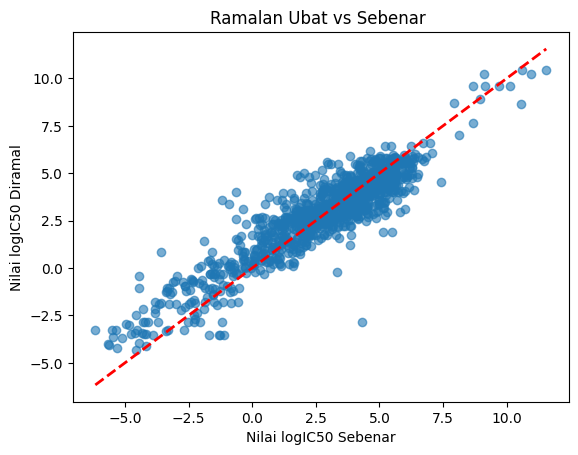

In [ ]:
import matplotlib.pyplot as plt

# Contoh untuk model Mutasi Gen
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)  # garis y=x untuk rujukan
plt.xlabel('Nilai logIC50 Sebenar')
plt.ylabel('Nilai logIC50 Diramal')
plt.title('Ramalan Ubat vs Sebenar ')
plt.show()
